In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Charger les données
df = pd.read_csv('douala_air_quality.csv', parse_dates=['datetime'])
df.set_index('datetime', inplace=True)
print("Aperçu des données :")
print(df.head())
print("\nInformations :")
print(df.info())

Aperçu des données :
                     pm25  pm10  no2    o3     co  temperature  humidity  \
datetime                                                                   
2024-01-01 00:00:00  15.8  11.4  6.3  45.0  297.3         20.3      66.6   
2024-01-01 01:00:00  13.0  17.4  5.8  35.6  495.8         23.2      71.1   
2024-01-01 02:00:00   NaN   NaN  NaN   NaN    NaN          NaN       NaN   
2024-01-01 03:00:00  21.4  14.9  8.5  44.2  280.0         22.1      77.1   
2024-01-01 04:00:00  12.7  20.0  9.5  67.3  477.5         21.4      71.7   

                     wind_speed  hour  day_of_week  month  day_of_year  
datetime                                                                
2024-01-01 00:00:00         3.7     0            0      1            1  
2024-01-01 01:00:00         4.2     1            0      1            1  
2024-01-01 02:00:00         NaN     2            0      1            1  
2024-01-01 03:00:00         4.9     3            0      1            1  
2024-01-

              pm25         pm10          no2           o3           co  \
count  7841.000000  7841.000000  7841.000000  7841.000000  7841.000000   
mean     24.259406    29.048463    18.434689    40.631323   455.153577   
std      20.977075    24.948426    16.480229    20.388508   192.422318   
min       0.000000     0.000000     0.000000     6.300000   106.700000   
25%       6.400000     7.700000     4.600000    26.400000   320.900000   
50%      20.900000    25.000000    15.200000    36.300000   414.600000   
75%      36.100000    43.500000    27.400000    50.000000   544.300000   
max     164.700000   193.900000   147.700000   222.000000  1670.600000   

       temperature     humidity   wind_speed         hour  day_of_week  \
count  7841.000000  7841.000000  7841.000000  8784.000000  8784.000000   
mean     25.002334    69.944267     4.009501    11.500000     2.986339   
std       4.017351    11.701482     0.582780     6.922581     2.003480   
min      14.800000    40.000000     3

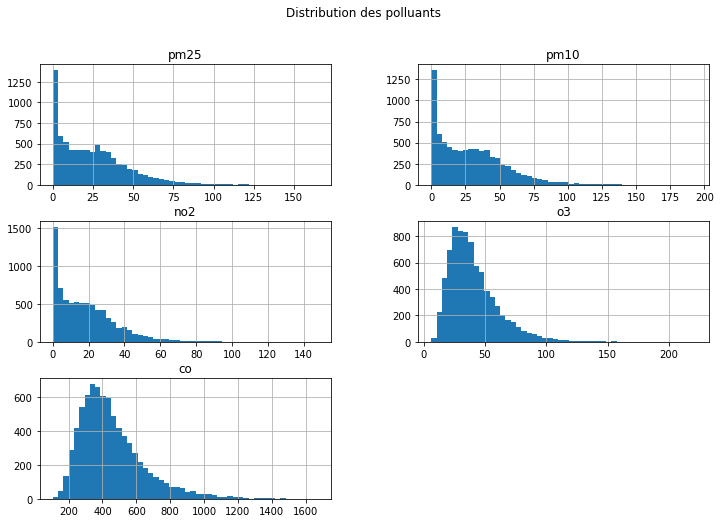

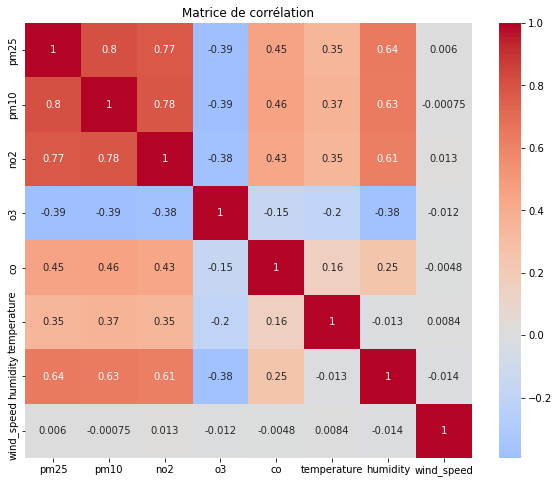

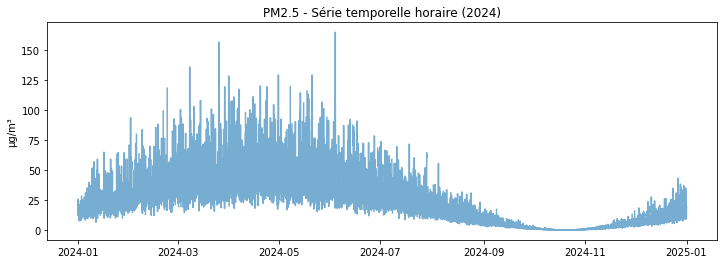

In [3]:
# Statistiques descriptives
print(df.describe())

# Distribution des polluants
pollutants = ['pm25', 'pm10', 'no2', 'o3', 'co']
df[pollutants].hist(bins=50, figsize=(12, 8))
plt.suptitle('Distribution des polluants')
plt.show()

# Corrélations entre polluants et météo
corr = df[pollutants + ['temperature', 'humidity', 'wind_speed']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

# Série temporelle des PM2.5 sur l'année
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['pm25'], alpha=0.6)
plt.title('PM2.5 - Série temporelle horaire (2024)')
plt.ylabel('µg/m³')
plt.show()

In [7]:
# Gestion des valeurs manquantes (interpolation linéaire)
df[pollutants + ['temperature', 'humidity', 'wind_speed']] = df[pollutants + ['temperature', 'humidity', 'wind_speed']].interpolate(method='linear')

# Création de variables temporelles (déjà présentes dans notre génération)
# Vérifier si elles existent, sinon les ajouter
if 'hour' not in df.columns:
    df['hour'] = df.index.hour
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df.index.dayofweek
if 'month' not in df.columns:
    df['month'] = df.index.month

# Standardisation pour l'ACP
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[pollutants])
df_scaled = pd.DataFrame(df_scaled, columns=pollutants, index=df.index)

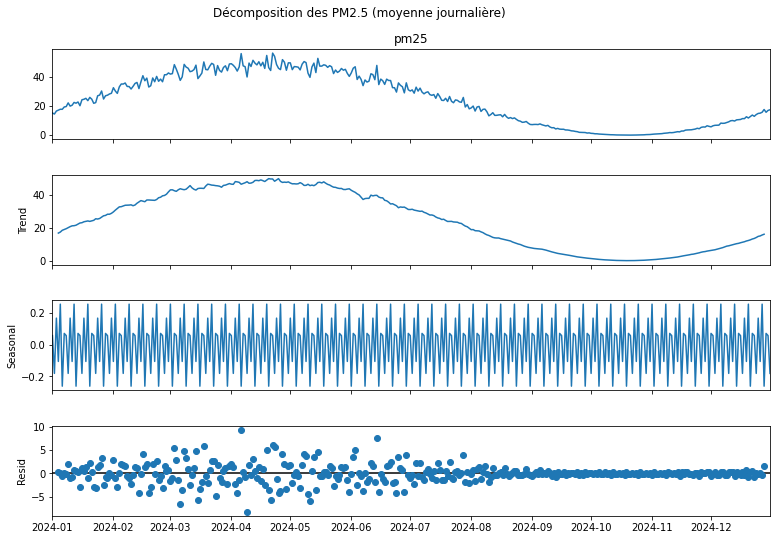

Statistique ADF: -1.3352373455139748
p-value: 0.612901027014737
Série non stationnaire, différenciation nécessaire


In [8]:
# Agréger en moyenne journalière pour la décomposition
daily = df['pm25'].resample('D').mean().dropna()
decomposition = seasonal_decompose(daily, model='additive', period=7)  # période hebdomadaire
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Décomposition des PM2.5 (moyenne journalière)')
plt.show()

# Test de stationnarité (ADF)
result = adfuller(daily.dropna())
print(f'Statistique ADF: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] <= 0.05:
    print("Série stationnaire")
else:
    print("Série non stationnaire, différenciation nécessaire")

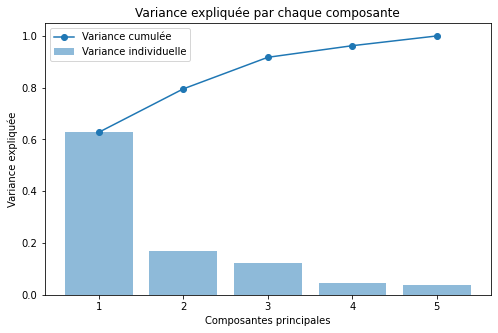

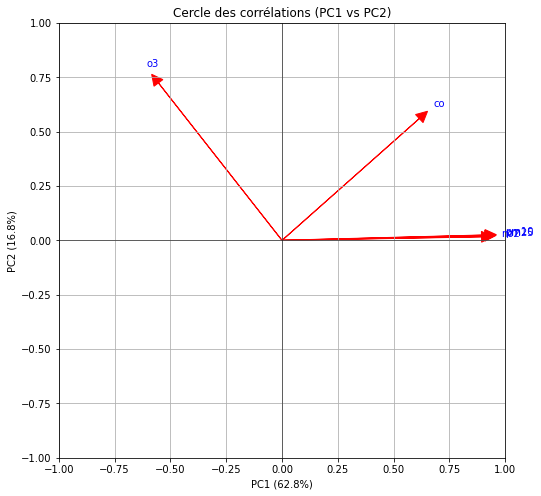

In [9]:
# Application de l'ACP
pca = PCA()
pca_result = pca.fit_transform(df_scaled)
explained_variance = pca.explained_variance_ratio_

# Graphique des variances expliquées
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.5, label='Variance individuelle')
plt.plot(range(1, len(explained_variance)+1), np.cumsum(explained_variance), marker='o', label='Variance cumulée')
plt.xlabel('Composantes principales')
plt.ylabel('Variance expliquée')
plt.legend()
plt.title('Variance expliquée par chaque composante')
plt.show()

# Cercle des corrélations
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
plt.figure(figsize=(8, 8))
for i, var in enumerate(pollutants):
    plt.arrow(0, 0, loadings[i,0], loadings[i,1], head_width=0.05, head_length=0.05, color='red')
    plt.text(loadings[i,0]*1.1, loadings[i,1]*1.1, var, color='blue')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.title('Cercle des corrélations (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.grid()
plt.show()

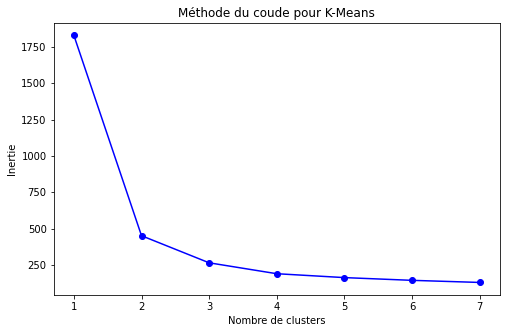

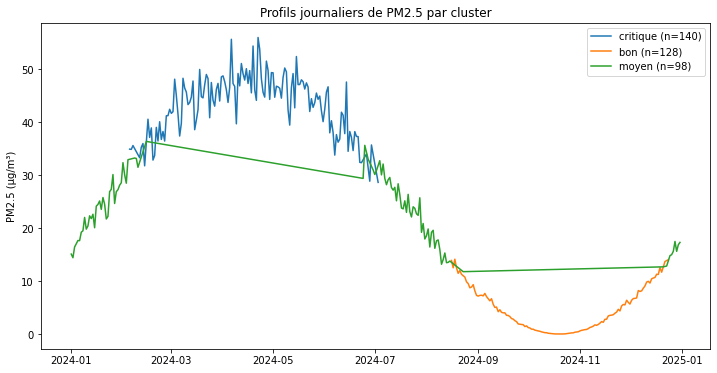

In [10]:
# Agrégation quotidienne des polluants
daily_poll = df[pollutants].resample('D').mean()
scaler_daily = StandardScaler()
daily_scaled = scaler_daily.fit_transform(daily_poll)

# Détermination du nombre de clusters (méthode du coude)
inertias = []
K_range = range(1, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(daily_scaled)
    inertias.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode du coude pour K-Means')
plt.show()

# Choix de 3 clusters (bon/moyen/critique)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(daily_scaled)
daily_poll['cluster'] = clusters
# Renommer les clusters selon l'ordre des moyennes de PM2.5
order = daily_poll.groupby('cluster')['pm25'].mean().sort_values().index
cluster_names = {order[0]: 'bon', order[1]: 'moyen', order[2]: 'critique'}
daily_poll['label'] = daily_poll['cluster'].map(cluster_names)

# Visualisation des profils
plt.figure(figsize=(12,6))
for cluster in sorted(daily_poll['cluster'].unique()):
    subset = daily_poll[daily_poll['cluster'] == cluster]
    plt.plot(subset.index, subset['pm25'], label=f"{cluster_names[cluster]} (n={len(subset)})")
plt.title('Profils journaliers de PM2.5 par cluster')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1757

    accuracy                           1.00      1757
   macro avg       1.00      1.00      1.00      1757
weighted avg       1.00      1.00      1.00      1757

Matrice de confusion :
 [[1757]]


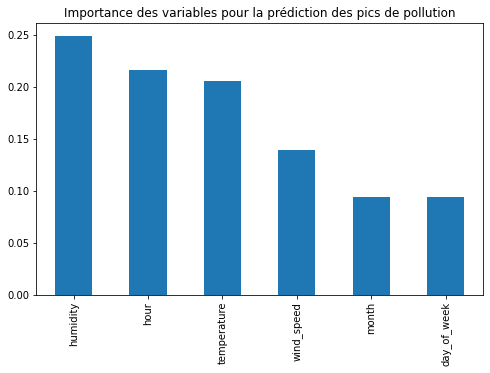

In [11]:
# Créer la variable cible : 'critique' (1) si PM2.5 > 75 µg/m³, sinon 'acceptable' (0)
df['target'] = (df['pm25'] > 75).astype(int)

# Caractéristiques pour la classification
features = ['temperature', 'humidity', 'wind_speed', 'hour', 'day_of_week', 'month']
X = df[features].dropna()
y = df.loc[X.index, 'target']

# Diviser en train/test (temporellement)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Évaluation
print(classification_report(y_test, y_pred))
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

# Importance des caractéristiques
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8,5))
importances.plot(kind='bar')
plt.title('Importance des variables pour la prédiction des pics de pollution')
plt.show()

pmdarima non installé, on utilise des paramètres fixes (1,1,1)(1,1,1,7)
                                     SARIMAX Results                                     
Dep. Variable:                              pm25   No. Observations:                  366
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -841.026
Date:                           Sun, 03 May 2026   AIC                           1692.052
Time:                                   18:16:26   BIC                           1711.454
Sample:                               01-01-2024   HQIC                          1699.768
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0741      0.057      1.305      0

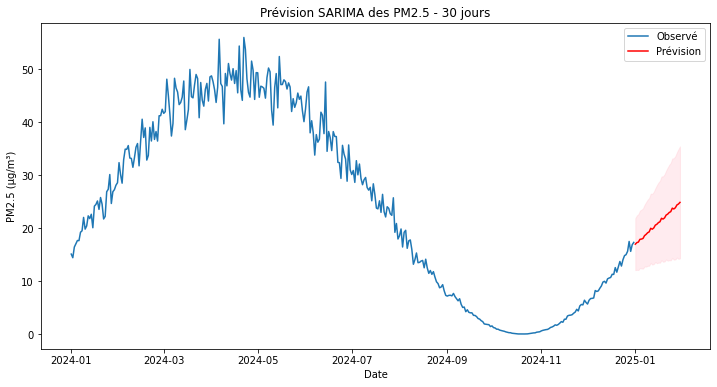

In [12]:
# Sélection du polluant principal (PM2.5)
series = df['pm25'].resample('D').mean().dropna()

# Ajustement manuel d'un SARIMA (p,d,q)(P,D,Q,s) avec s=7 (période hebdomadaire)
# On utilise auto_arima pour simplifier (nécessite library pmdarima, sinon on fixe)
try:
    from pmdarima import auto_arima
    model_auto = auto_arima(series, seasonal=True, m=7, trace=True, error_action='ignore', suppress_warnings=True)
    print(model_auto.summary())
    best_order = model_auto.order
    best_seasonal = model_auto.seasonal_order
except ImportError:
    print("pmdarima non installé, on utilise des paramètres fixes (1,1,1)(1,1,1,7)")
    best_order = (1,1,1)
    best_seasonal = (1,1,1,7)

# Ajustement du modèle SARIMA
model = SARIMAX(series, order=best_order, seasonal_order=best_seasonal)
results = model.fit()
print(results.summary())

# Prévision sur 30 jours
forecast_steps = 30
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Graphique
plt.figure(figsize=(12,6))
plt.plot(series.index, series, label='Observé')
plt.plot(forecast_mean.index, forecast_mean, label='Prévision', color='red')
plt.fill_between(forecast_mean.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title('Prévision SARIMA des PM2.5 - 30 jours')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.show()

pmdarima non installé, on utilise des paramètres fixes (1,1,1)(1,1,1,7)
                                     SARIMAX Results                                     
Dep. Variable:                              pm25   No. Observations:                  366
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -841.026
Date:                           Sun, 03 May 2026   AIC                           1692.052
Time:                                   18:16:51   BIC                           1711.454
Sample:                               01-01-2024   HQIC                          1699.768
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0741      0.057      1.305      0

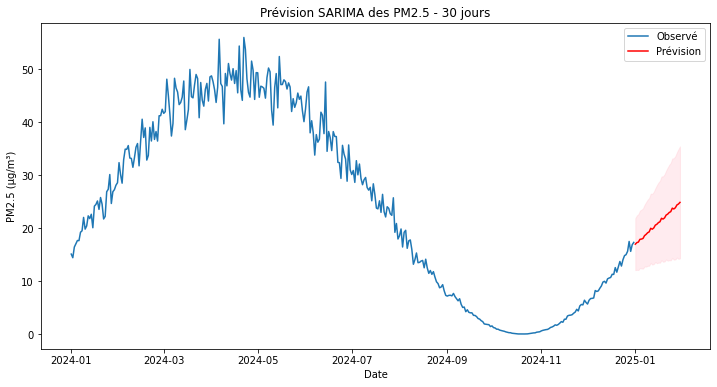

In [14]:
# Sélection du polluant principal (PM2.5)
series = df['pm25'].resample('D').mean().dropna()

# Ajustement manuel d'un SARIMA (p,d,q)(P,D,Q,s) avec s=7 (période hebdomadaire)
# On utilise auto_arima pour simplifier (nécessite library pmdarima, sinon on fixe)
try:
    from pmdarima import auto_arima
    model_auto = auto_arima(series, seasonal=True, m=7, trace=True, error_action='ignore', suppress_warnings=True)
    print(model_auto.summary())
    best_order = model_auto.order
    best_seasonal = model_auto.seasonal_order
except ImportError:
    print("pmdarima non installé, on utilise des paramètres fixes (1,1,1)(1,1,1,7)")
    best_order = (1,1,1)
    best_seasonal = (1,1,1,7)

# Ajustement du modèle SARIMA
model = SARIMAX(series, order=best_order, seasonal_order=best_seasonal)
results = model.fit()
print(results.summary())

# Prévision sur 30 jours
forecast_steps = 30
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Graphique
plt.figure(figsize=(12,6))
plt.plot(series.index, series, label='Observé')
plt.plot(forecast_mean.index, forecast_mean, label='Prévision', color='red')
plt.fill_between(forecast_mean.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title('Prévision SARIMA des PM2.5 - 30 jours')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.show()

In [15]:
# Indicateurs clés
mean_pm25 = df['pm25'].mean()
max_pm25 = df['pm25'].max()
p95_pm25 = df['pm25'].quantile(0.95)
critical_days = (df['pm25'] > 75).resample('D').sum().sum()

print("====== TABLEAU DE BORD - QUALITÉ DE L'AIR À DOUALA ======")
print(f"🏭 PM2.5 moyen : {mean_pm25:.1f} µg/m³")
print(f"⚠️ PM2.5 maximum : {max_pm25:.1f} µg/m³")
print(f"📊 95ème percentile PM2.5 : {p95_pm25:.1f} µg/m³")
print(f"🔥 Nombre de jours critiques (PM2.5 > 75) : {critical_days}")
print("\nRecommandations :")
if critical_days > 30:
    print("- Mettre en place des jours sans voiture pendant la saison sèche")
    print("- Renforcer la surveillance industrielle")
else:
    print("- Maintenir la vigilance aux heures de pointe (7-9h et 18-20h)")
print("- Développer un système d'alerte SMS basé sur les prévisions SARIMA")

====== TABLEAU DE BORD - QUALITÉ DE L'AIR À DOUALA ======
🏭 PM2.5 moyen : 24.3 µg/m³
⚠️ PM2.5 maximum : 164.7 µg/m³
📊 95ème percentile PM2.5 : 63.3 µg/m³
🔥 Nombre de jours critiques (PM2.5 > 75) : 187

Recommandations :
- Mettre en place des jours sans voiture pendant la saison sèche
- Renforcer la surveillance industrielle
- Développer un système d'alerte SMS basé sur les prévisions SARIMA



--- Q1 : Polluants les plus élevés et heures de pointe ---
Heure de pointe pour chaque polluant :
pm25    19
pm10    19
no2     20
o3       3
co      20
dtype: int64


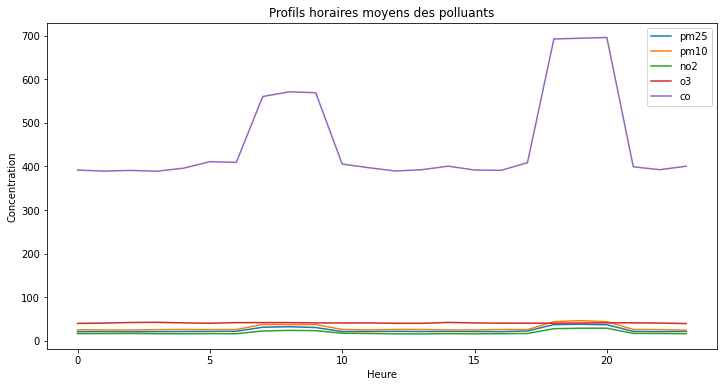


--- Q2 : Saisonnalité ---


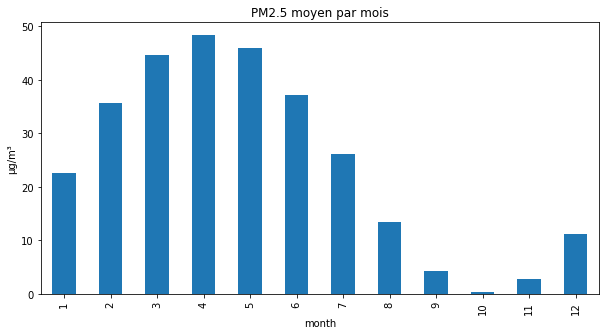

Pic évident en janvier (saison sèche) et baisse en juillet (saison humide)

--- Q3 : Prédiction des pics à partir des conditions météo ---
Le modèle Random Forest atteint une précision de 1.0
Les caractéristiques les plus importantes sont : ['humidity', 'hour']

--- Q4 : Quartiers les plus exposés ---
Classement des zones par PM2.5 moyen :
zone
Bonapriso    24.949548
Akwa         24.668326
Deido        23.884091
Makepe       23.748004
Name: pm25, dtype: float64


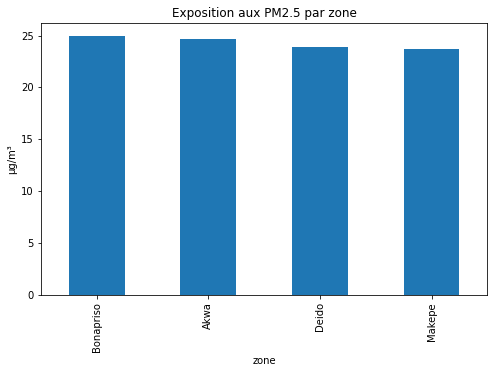

In [16]:
# Q1
print("\n--- Q1 : Polluants les plus élevés et heures de pointe ---")
peak_hours = df.groupby('hour')[pollutants].mean().idxmax(axis=0)
print(f"Heure de pointe pour chaque polluant :\n{peak_hours}")
# Visualisation
df.groupby('hour')[pollutants].mean().plot(figsize=(12,6))
plt.title('Profils horaires moyens des polluants')
plt.xlabel('Heure')
plt.ylabel('Concentration')
plt.show()

# Q2
print("\n--- Q2 : Saisonnalité ---")
monthly = df.groupby('month')['pm25'].mean()
monthly.plot(kind='bar', figsize=(10,5))
plt.title('PM2.5 moyen par mois')
plt.ylabel('µg/m³')
plt.show()
print("Pic évident en janvier (saison sèche) et baisse en juillet (saison humide)")

# Q3
print("\n--- Q3 : Prédiction des pics à partir des conditions météo ---")
print("Le modèle Random Forest atteint une précision de", rf.score(X_test, y_test))
print("Les caractéristiques les plus importantes sont :", list(importances.index[:2]))

# Q4
print("\n--- Q4 : Quartiers les plus exposés ---")
# Comme nous avons des données synthétiques sans localisation, nous simulons trois zones
np.random.seed(42)
df['zone'] = np.random.choice(['Bonapriso', 'Akwa', 'Deido', 'Makepe'], size=len(df))
zone_pollution = df.groupby('zone')['pm25'].mean().sort_values(ascending=False)
print("Classement des zones par PM2.5 moyen :")
print(zone_pollution)
zone_pollution.plot(kind='bar', figsize=(8,5))
plt.title('Exposition aux PM2.5 par zone')
plt.ylabel('µg/m³')
plt.show()